# День 08. Упражнение 04
# Регрессия

## 0. Импорты

In [1]:
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

## 1. Предобработка

1. Прочитай файл [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Заполни пропущенные значения нулями (`0`).
3. Раздели набор данных на обучающую и тестовую выборки с параметрами `test_size=0.2`.

In [24]:
df=pd.read_csv('../data/checker_regression.csv')

In [23]:
df.fillna(0,inplace=True)

,uid,num_commits,pageviews,AVG(diff),uid_codes
0,user_1,62,28.0,0.00,0
1,user_1,62,28.0,0.00,0
2,user_1,62,28.0,0.00,0
3,user_1,62,28.0,0.00,0
4,user_1,62,28.0,0.00,0
...,...,...,...,...,...
72,user_31,128,0.0,-104.75,24
73,user_4,40,0.0,-175.60,25
74,user_6,15,0.0,-62.60,26
75,user_7,8,0.0,-115.50,27


In [22]:
codes, uniques=pd.factorize(df['uid'])
df['uid_codes']=codes

In [15]:
X=df[['num_commits','pageviews', 'uid_codes']]
y=df['AVG(diff)']
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_train, X_test, y_train, y_test= train_test_split(X_scaled, y, test_size=0.2, random_state=21)

## 2. Кросс-валидация

1. Напиши функцию `crossval`, которая принимает аргументы: `n_splits` для `KFold()`, `X`, `y`, модель (инициализированный класс с параметрами модели; не забудь о `random_state=21`) и возвращает для данного класса модели результат в таком виде:

```
train - 2696.4496895424836 | test - 1589.9979527104958
train - 2660.957874001452 | test - 2075.102636027137
train - 2847.315529246795 | test - 320.911928168403
train - 2500.7691099659237 | test - 4132.461382030178
train - 2643.927917295123 | test - 2237.8140952197878
train - 2396.295678819444 | test - 4509.650064742476
train - 2003.402267924976 | test - 8403.491474908551
train - 2531.876094212613 | test - 3135.944102735099
train - 2683.1795186023123 | test - 1796.01426292594
train - 2537.1192483996338 | test - 3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Запусти функцию для моделей `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. Параметры можешь выбрать самостоятельно, но тщательно убедись, что они подходят.

In [16]:
def crossval(n_splits, X, y, model):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=21)
    rmse_list = []

    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_train, y_train)

        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        rmse_train = mean_squared_error(y_train, y_pred_train)
        rmse_test = mean_squared_error(y_test, y_pred_test)

        rmse_list.append(rmse_test)

        print(f"train - {rmse_train:<20} |   test - {rmse_test}")

    print(f"Average RMSE on crossval is {np.mean(rmse_list)}")

In [17]:
linear = LinearRegression()
crossval(10, X_scaled, y, linear)

train - 1441.1429446615782   |   test - 4363.822385412787
train - 1785.9386282352104   |   test - 1328.019337809866
train - 1907.1374456640067   |   test - 270.2825181651495
train - 1594.7939381460933   |   test - 3172.826687369627
train - 1761.9879544494338   |   test - 1524.044664138978
train - 1891.2205046752322   |   test - 428.980245315449
train - 1671.5311914343833   |   test - 2656.145908579817
train - 1884.4647010691426   |   test - 262.97047485829523
train - 1719.5519955218504   |   test - 2169.5169747525024
train - 1570.7543918892582   |   test - 3740.0850633468194
Average RMSE on crossval is 1991.6694259749288


In [18]:
tree = DecisionTreeRegressor(max_depth=4, random_state=21)
crossval(10, X_scaled, y, tree)

train - 158.99594202898547   |   test - 4577.8275
train - 240.4017901234568    |   test - 205.03125
train - 242.75162909286098   |   test - 0.0
train - 172.351384057971     |   test - 411.8450000000001
train - 69.83359366612989    |   test - 3562.23092978395
train - 120.46939881910895   |   test - 30.03125
train - 57.94242351046698    |   test - 785.4955902777779
train - 95.23041058201058    |   test - 2059.543557142857
train - 38.312878968253976   |   test - 4988.421785714286
train - 197.8225373677249    |   test - 687.179129464286
Average RMSE on crossval is 1730.7605992383155


In [19]:
forest = RandomForestRegressor(random_state=21)
crossval(10, X_scaled, y, forest)

train - 105.78368795611917   |   test - 3319.0074774444456
train - 153.5900635692432    |   test - 189.68001068055574
train - 157.03564593880856   |   test - 0.0
train - 176.05050118115886   |   test - 700.0970170138893
train - 156.78533707206097   |   test - 2375.898122795144
train - 185.6872019730269    |   test - 680.3622719999996
train - 177.41081999838968   |   test - 1392.2432888888893
train - 156.0644039753964    |   test - 1555.113175000001
train - 186.55295501230148   |   test - 1454.162019706348
train - 162.5019098880949    |   test - 921.4205880714262
Average RMSE on crossval is 1258.7983971600697


## 3. Предсказания и оценка

1. Сделай предсказания на тестовом наборе данных для каждой из трёх моделей с финальными параметрами.
2. Построй график для каждой модели, где по оси x — фактическая средняя разница, а по оси y — предсказание модели.
3. Как должен выглядеть график в идеальном случае? Напиши ответ в markdown-ячейке в конце раздела.

In [20]:
y_pred_linear = linear.predict(X_test)
y_pred_tree = tree.predict(X_test)
y_pred_forest = forest.predict(X_test)

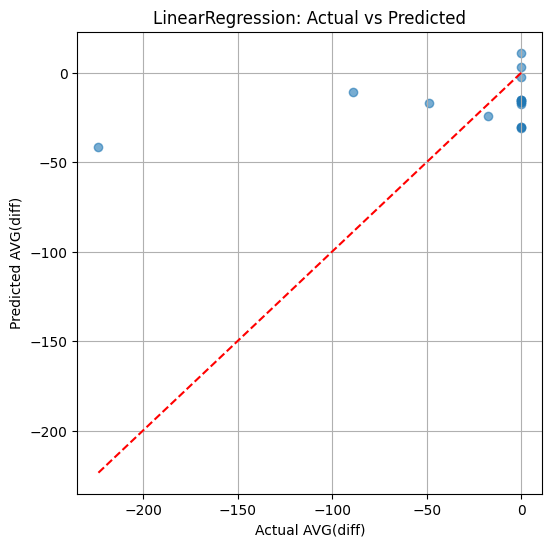

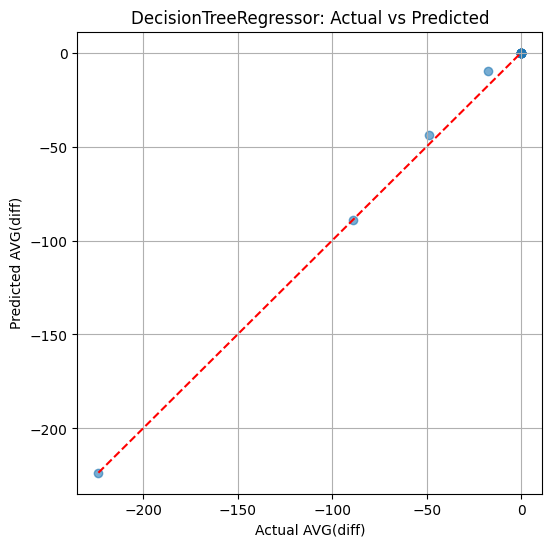

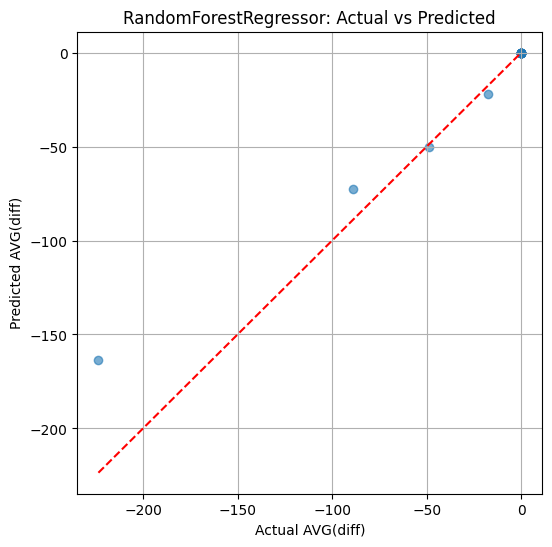

In [21]:
import matplotlib.pyplot as plt

models = {
    "LinearRegression": y_pred_linear,
    "DecisionTreeRegressor": y_pred_tree,
    "RandomForestRegressor": y_pred_forest
}

for model_name, y_pred in models.items():
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.xlabel("Actual AVG(diff)")
    plt.ylabel("Predicted AVG(diff)")
    plt.title(f"{model_name}: Actual vs Predicted")
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # линия идеала
    plt.grid(True)
    plt.show()

Диагональ